In [1]:
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

# Check device (MPS for Apple GPU)
device = "mps" if torch.backends.mps.is_available() else "cpu"
print("Using device:", device)

/Users/jadavakshayrao/arabert_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


In [2]:
# Load your dataset
df = pd.read_csv("arabic_dataset_classifiction.csv")

# Rename and clean columns
df = df.rename(columns={"targe": "target"})
df = df.dropna(subset=["text", "target"])
df["target"] = df["target"].astype(int)

# Split data
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["target"])
print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 87031
Test size: 21758


In [3]:
# ✅ Rename 'target' column to 'labels' so the Trainer can compute loss automatically
train_df = train_df.rename(columns={"target": "labels"})
test_df = test_df.rename(columns={"target": "labels"})

# Convert to Hugging Face datasets
train_ds = Dataset.from_pandas(train_df)
test_ds = Dataset.from_pandas(test_df)

In [4]:
# Tokenization
model_name = "aubmindlab/bert-base-arabertv2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

train_ds = train_ds.map(tokenize_fn, batched=True)
test_ds = test_ds.map(tokenize_fn, batched=True)

# Set correct format with labels column
train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

print("Columns in dataset:", train_ds.column_names)

Map: 100%|██████████████████████| 21758/21758 [00:02<00:00, 10371.50 examples/s]

Columns in dataset: ['text', 'labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask']


In [5]:
from transformers import AutoModelForSequenceClassification

num_labels = df["target"].nunique()
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels).to("mps")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
from transformers import TrainingArguments

args = TrainingArguments(
    output_dir="./arabert-output",
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=2,
    learning_rate=2e-5,
    logging_steps=100,
    save_total_limit=2,
    load_best_model_at_end=True,
    report_to=[],  # disables wandb
)

In [7]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# Load the saved model
save_dir = "./arabert_finetuned_model"
tokenizer = AutoTokenizer.from_pretrained(save_dir)
model = AutoModelForSequenceClassification.from_pretrained(save_dir)

print("Model reloaded successfully!")

# Recreate the Trainer
trainer = Trainer(
    model=model,
    args=args,
    eval_dataset=test_ds,   # reuse the preprocessed test_ds
    tokenizer=tokenizer
)

# ✅ Now you can evaluate without retraining
predictions = trainer.predict(test_ds)


Model reloaded successfully!


/var/folders/37/k5bnxz5n2txbbz0q3xmnjq7c0000gn/T/ipykernel_8048/95514014.py:11: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/Users/jadavakshayrao/arabert_env/lib/python3.14/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [8]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Extract logits and labels
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

# Compute Accuracy
acc = accuracy_score(labels, preds)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9613


In [9]:
print("\n Classification Report:")
print(classification_report(labels, preds))


 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      2747
           1       0.97      0.98      0.97      3346
           2       0.91      0.92      0.91      2833
           3       0.92      0.92      0.92      4097
           4       0.99      0.99      0.99      8735

    accuracy                           0.96     21758
   macro avg       0.95      0.95      0.95     21758
weighted avg       0.96      0.96      0.96     21758



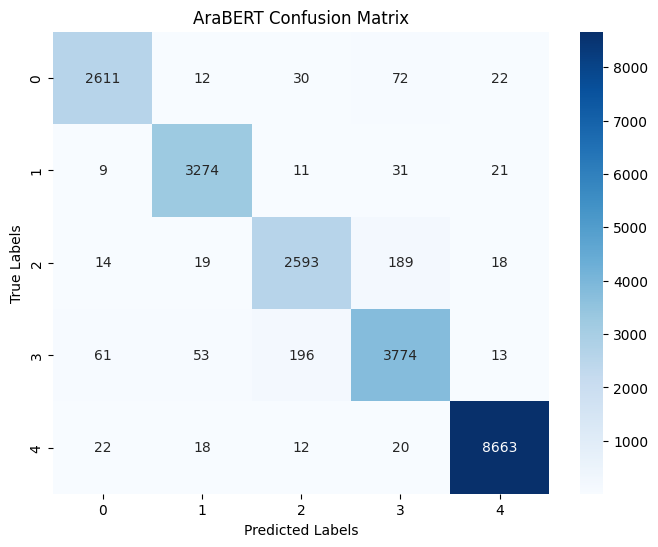

In [10]:
# Compute confusion matrix
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("AraBERT Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()